In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from pathlib import Path
import pandas as pd
import numpy as np

SEED = 2580

### Reading Ham-Spam Dataset

In [2]:
DATA_DIR = Path("data")
CSV_PATH = DATA_DIR / "HamSpam_dataset.csv"

df = pd.read_csv(CSV_PATH)

### Inspect rows

In [3]:
print(df[:10])

  label                                        description
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                  Ok lar... Joking with you only...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  you dun say so early hor... you c already then...
4   ham  Nah I don't think he goes to usf, he lives aro...
5  spam  FreeMsg Hey there darling it's been 3 week's n...
6   ham  Even my brother is not like to speak with me. ...
7   ham  As per your request 'Melle Melle (Oru Minnamin...
8  spam  WINNER!! As a valued network customer you have...
9  spam  Had your mobile 11 months or more? you are ent...


### description -> X, label -> Y

In [4]:
X = df["description"]
y = df["label"]

In [5]:
print(X)

0        Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking with you only...
2        Free entry in 2 a wkly comp to win FA Cup fina...
3        you dun say so early hor... you c already then...
4        Nah I don't think he goes to usf, he lives aro...
                               ...                        
73890    to whom this may concern : please note that co...
73891    greg , dale nesbitt is a consultant who develo...
73892    my latest information on rate increases in cal...
73893    correct numbers are teco tap 100 . 833 / hpl i...
73894    secrets revealed . how do porn stars perform ,...
Name: description, Length: 73895, dtype: str


In [6]:
print(y)

0         ham
1         ham
2        spam
3         ham
4         ham
         ... 
73890     ham
73891     ham
73892     ham
73893     ham
73894    spam
Name: label, Length: 73895, dtype: str


### Spam -> 1, Ham -> 0

In [7]:
y = y.map({"spam": 1, "ham": 0})
print(y)

0        0
1        0
2        1
3        0
4        0
        ..
73890    0
73891    0
73892    0
73893    0
73894    1
Name: label, Length: 73895, dtype: int64


### Split into train, validate and test

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

In [9]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

In [10]:
print("Training examples: ", len(X_train))
print("Validation examples: ", len(X_val))
print("Test examples: ", len(X_test))

Training examples:  51726
Validation examples:  11084
Test examples:  11085


### Initialize vectorizer object

In [11]:
vectorizer = TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1,4), min_df=3)

### Learn vocabulary and IDF from train, then compute TF-IDF matrix

In [12]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [13]:
print(X_train_tfidf.shape)

(51726, 684219)


### Convert validation set to the corresponding TFIDF matrix

In [14]:
X_val_tfidf = vectorizer.transform(X_val)

### Initialize and train logistic regression model on train split, for different regularization values and analyze train and validation accuracies

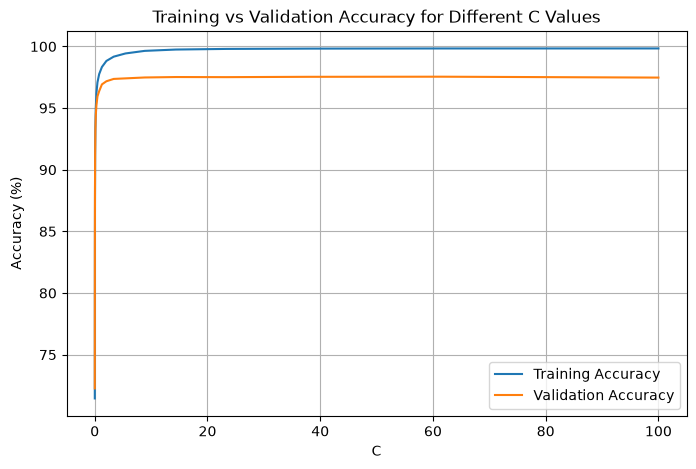

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

C_values = np.logspace(-2, 2, 20)

train_accuracies = []
val_accuracies = []

for c in C_values:
    model = LogisticRegression(random_state=SEED, solver='liblinear', C = c)
    model.fit(X_train_tfidf, y_train)

    train_pred = model.predict(X_train_tfidf)
    train_accuracies.append(accuracy_score(y_train, train_pred) * 100)
    # print(classification_report(y_train, train_pred))

    val_pred = model.predict(X_val_tfidf)
    val_accuracies.append(accuracy_score(y_val, val_pred) * 100)
    # print(classification_report(y_val, val_pred))

plt.figure(figsize=(8, 5))

plt.plot(C_values, train_accuracies, label="Training Accuracy")
plt.plot(C_values, val_accuracies, label="Validation Accuracy")

plt.xlabel("C")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy for Different C Values")

plt.legend()
plt.grid(True)
plt.show()

In [16]:
best_idx = np.argmax(val_accuracies)
best_C = C_values[best_idx]
print("Best C:", best_C)

model = LogisticRegression(random_state=SEED, solver='liblinear', C = best_C)

model.fit(X_train_tfidf, y_train)
train_pred = model.predict(X_train_tfidf)

print(f'Train accuracy - {accuracy_score(y_train, train_pred) * 100: .2f}%')
print(classification_report(y_train, train_pred))

val_pred = model.predict(X_val_tfidf)

print(f'Validation accuracy - {accuracy_score(y_val, val_pred) * 100: .2f}%')
print(classification_report(y_val, val_pred))

Best C: 61.584821106602604
Train accuracy -  99.84%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30070
           1       1.00      1.00      1.00     21656

    accuracy                           1.00     51726
   macro avg       1.00      1.00      1.00     51726
weighted avg       1.00      1.00      1.00     51726

Validation accuracy -  97.55%
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      6444
           1       0.98      0.97      0.97      4640

    accuracy                           0.98     11084
   macro avg       0.98      0.97      0.97     11084
weighted avg       0.98      0.98      0.98     11084



### Retrain model with combined dataset (Train + Validate)

In [17]:
X_train_val = pd.concat([X_train, X_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)

X_train_val_tfidf = vectorizer.fit_transform(X_train_val)
X_test_tfidf = vectorizer.transform(X_test)

In [18]:
model.fit(X_train_val_tfidf, y_train_val)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(61.584821106602604)
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",2580
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` g

### **Model Inference on Test split**

In [19]:
test_pred = model.predict(X_test_tfidf)

In [20]:
print(f'Test accuracy - {accuracy_score(y_test, test_pred) * 100: .2f}%')
print(classification_report(y_test, test_pred))

Test accuracy -  97.58%
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      6444
           1       0.98      0.97      0.97      4641

    accuracy                           0.98     11085
   macro avg       0.98      0.97      0.98     11085
weighted avg       0.98      0.98      0.98     11085



In [21]:
test_results = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "ground_truth": y_test.reset_index(drop=True),
    "prediction": pd.Series(test_pred)
})

print(test_results[:10])

                                                text  ground_truth  prediction
0  learn how to realize " p r o f i t s " of 100 ...             1           1
1  did you know that    ? ? ? fact : every ele...             1           1
2  This is the 2nd time we have tried 2 contact y...             1           1
3  Good FRIENDS CaRE for each Other.. CLoSE Frien...             0           0
4  Are we still on for dinner tonight? Let me kno...             0           0
5  i ' m preparing a " cheat sheet " for steve fo...             0           0
6  already i was created a small whatsapp group s...             1           1
7  make her wake up the neighbors your new 9 inch...             1           1
8  fyi . - - - - - original message - - - - - fro...             0           0
9  martin adamson martin srv1635465 ems ed ac uk ...             0           0


In [22]:
print("Mismatched rows: ")

for i in range(len(test_results)):
    if(test_results.loc[i]["ground_truth"] != test_results.loc[i]["prediction"]):
        print(test_results.loc[i])

Mismatched rows: 
text            socijalisticka partija srbije predvodjena grup...
ground_truth                                                    1
prediction                                                      0
Name: 22, dtype: object
text            with my family booking tour package.
ground_truth                                       0
prediction                                         1
Name: 127, dtype: object
text            holiday shopping support the rise school of ho...
ground_truth                                                    0
prediction                                                      1
Name: 132, dtype: object
text            online h
ground_truth           0
prediction             1
Name: 137, dtype: object
text            “uzbekistan airways”нинг нархлари хорижий авиа...
ground_truth                                                    1
prediction                                                      0
Name: 144, dtype: object
text            i cant explain